# Events Information

[Event Slicer](https://github.com/uzh-rpg/DSEC/blob/main/scripts/utils/eventslicer.py): Python code from DSEC used to retrieve event data

In [1]:
from framework.utils.dsec.eventslicer import EventSlicer
from framework.utils.h5_functions import set_offset

In [2]:
import h5py
import hdf5plugin

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)

/home/j_zarcoo/Documents/snn/framework


# DSEC

In [7]:
event_path = (
    PROJECT_ROOT
    / "data"
    / "zurich_city_13_a"
    / "zurich_city_13_a_events_left"
    / "events.h5"
)
print(event_path.exists())

True


In [8]:
h5f = h5py.File(event_path, 'r')
event_slicer = EventSlicer(h5f)

In [9]:
print(f"Start time (us): {event_slicer.get_start_time_us()}")
print(f"Final time (us): {event_slicer.get_final_time_us()}")
print(f"Offset (us): {event_slicer.t_offset}")

Start time (us): 41616099917
Final time (us): 41635000916
Offset (us): 41616099917


In [10]:
for key, value in event_slicer.events.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

  p: shape=(152299794,), dtype=uint8
  x: shape=(152299794,), dtype=uint16
  y: shape=(152299794,), dtype=uint16
  t: shape=(152299794,), dtype=uint32


In [11]:
# Retrieve events for the specified time window
# dsec_events = event_slicer.get_events(event_slicer.get_start_time_us(), event_slicer.get_final_time_us())

# Framework

In [12]:

PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)

/home/j_zarcoo/Documents/snn/framework


In [13]:
experiment_path = (
    PROJECT_ROOT
    / "results"
    / "zurich_city_13_a_events.h5"
)
print(experiment_path.exists())

True


- threshold: 6
- min_pixels: 0

In [14]:
# Change offset
set_offset(experiment_path, event_slicer.t_offset)

In [15]:
experiment_h5f = h5py.File(experiment_path, 'r')
experiment_h5f_slicer = EventSlicer(experiment_h5f)

In [16]:
print(f"Start time (us): {experiment_h5f_slicer.get_start_time_us()}")
print(f"Final time (us): {experiment_h5f_slicer.get_final_time_us()}")
print(f"Offset (us): {experiment_h5f_slicer.t_offset}")

Start time (us): 41616099917
Final time (us): 41634949917
Offset (us): 41616099917


In [17]:
for key, value in experiment_h5f_slicer.events.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

  p: shape=(27891565,), dtype=uint8
  x: shape=(27891565,), dtype=uint16
  y: shape=(27891565,), dtype=uint16
  t: shape=(27891565,), dtype=uint32


In [18]:
# Retrieve events for the specified time window
# experiment_events = experiment_h5f_slicer.get_events(experiment_h5f_slicer.get_start_time_us(), experiment_h5f_slicer.get_final_time_us())

# Stats

In [19]:
def get_stats(event_slicer):
    """
    Calculate statistics for a given event slicer.

    Args:
        event_slicer (EventSlicer): An instance of the EventSlicer class.

    Returns:
        dict: A dictionary containing the following statistics:
            - 'events': Total number of events.
            - 'positive': Number of positive events (polarity = 1).
            - 'negative': Number of negative events (polarity = 0).
            - 'duration_us': Duration of the events in microseconds.
            - 'events_per_second': Average number of events per second.
            - 'min_timestamp': Minimum timestamp of the events.
            - 'max_timestamp': Maximum timestamp of the events.
    """
    start = event_slicer.get_start_time_us()
    end = event_slicer.get_final_time_us()

    # 1 second
    window = 1_000_000

    total = 0
    positive = 0
    negative = 0

    first_t = None
    last_t = None

    for t0 in range(start, end, window):
        t1 = min(t0 + window, end)

        evs = event_slicer.get_events(t0, t1)

        if len(evs["t"]) == 0:
            continue

        if first_t is None:
            first_t = evs["t"][0]

        last_t = evs["t"][-1]

        total += len(evs["t"])
        positive += np.count_nonzero(evs["p"] == 1)
        negative += np.count_nonzero(evs["p"] == 0)
    
    return {
        "events": total,
        "positive": positive,
        "negative": negative,
        "duration_us": last_t - first_t if first_t is not None and last_t is not None else 0,
        "events_per_second": total / ((last_t - first_t) / 1_000_000) if first_t is not None and last_t is not None and (last_t - first_t) > 0 else 0,
        "min_timestamp": first_t,
        "max_timestamp": last_t,
    }

In [20]:
print("DSEC")
dsec_stats = get_stats(event_slicer)
print(f"min_timestamp: {dsec_stats['min_timestamp']}")
print(f"max_timestamp: {dsec_stats['max_timestamp']}")

print("\nFramework")
experiment_stats = get_stats(experiment_h5f_slicer)
print(f"min_timestamp: {experiment_stats['min_timestamp']}")
print(f"max_timestamp: {experiment_stats['max_timestamp']}")

DSEC


min_timestamp: 41616099917
max_timestamp: 41635000915

Framework
min_timestamp: 41616099917
max_timestamp: 41634899917


In [21]:
df_stats = pd.DataFrame({
    'DSEC': dsec_stats,
    'Framework': experiment_stats
}, index=['events', 'positive', 'negative', 'events_per_sec'])

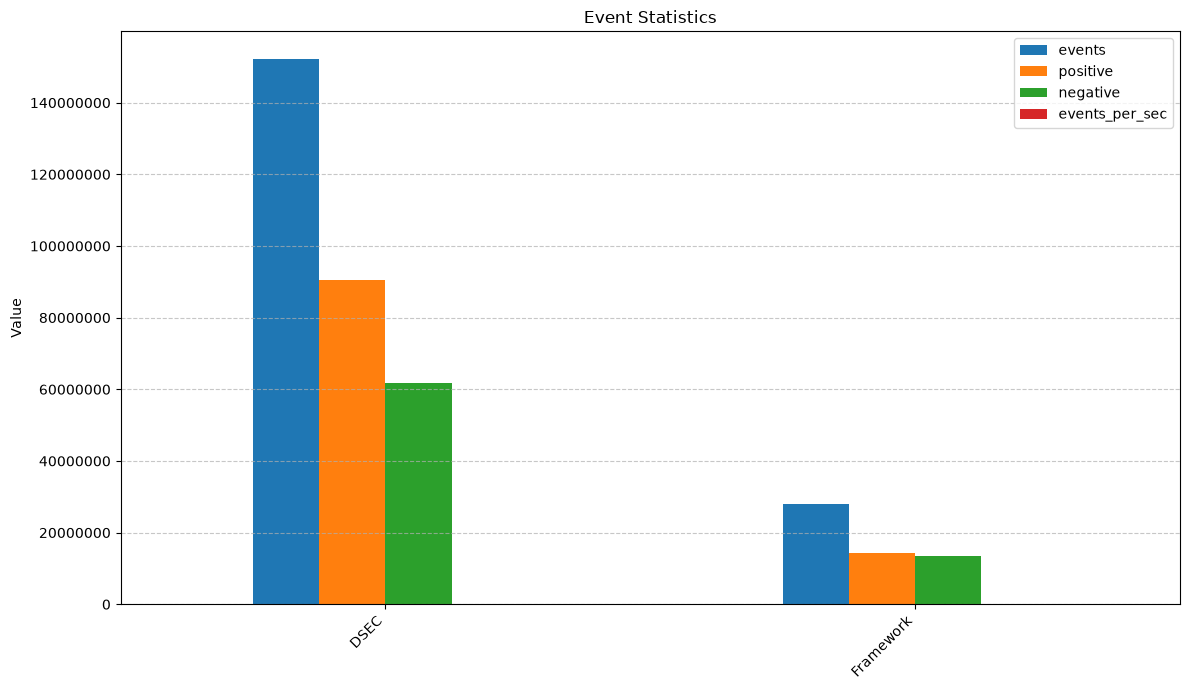

In [22]:
metrics_to_plot = ['events', 'positive', 'negative', 'events_per_sec']
plot_df = df_stats.loc[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 7))
plot_df.T.plot(kind='bar', ax=ax)

ax.set_title('Event Statistics')
ax.set_ylabel('Value')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
percentage_events = (df_stats.loc['events', 'Framework'] / df_stats.loc['events', 'DSEC']) * 100
print(f"Percentage of events of the framework compared to DSEC: {percentage_events:.2f}%")

Percentage of events of the framework compared to DSEC: 18.29%


In [24]:
df_stats.loc['events', 'DSEC'] 

np.float64(152299792.0)

In [25]:
df_stats.loc['events', 'Framework'] 

np.float64(27855931.0)